In [42]:
pip install pytesseract

In [43]:
import os
import cv2
import numpy as np
import pytesseract
from PIL import Image
import re
from datetime import datetime

class DocumentProcessor:
    """
    Handles document scanning and information extraction for voice banking integration.
    Supports various document types including ID cards, bank statements, and payment slips.
    """

    def __init__(self, tesseract_path=None):
        """
        Initialize the document processor with optional tesseract path configuration.

        Args:
            tesseract_path: Path to tesseract executable (if not in PATH)
        """
        # Configure tesseract path if provided
        if tesseract_path:
            pytesseract.pytesseract.tesseract_cmd = tesseract_path

        # Document type patterns
        self.document_patterns = {
            'id_card': {
                'name': r'(?:Name|NAME)[\s:]+([A-Z\s]+)',
                'id_number': r'(?:ID|id|No|NO)[\s.:]+([A-Z0-9-]+)',
                'expiry': r'(?:Expiry|Valid until|VALID THRU)[\s:]+(\d{2}[/.-]\d{2}[/.-]\d{2,4})'
            },
            'bank_statement': {
                'account_number': r'(?:Account|ACCOUNT|A/C)[\s#.:]+(\d{8,22})',
                'balance': r'(?:Balance|BALANCE|Available)[\s:]+[$€£]?(\d+[,.]?\d*)',
                'date': r'(?:Statement Date|Date)[\s:]+(\d{1,2}[/.-]\d{1,2}[/.-]\d{2,4})'
            },
            'payment_slip': {
                'amount': r'(?:Amount|AMOUNT|Total)[\s:]+[$€£]?(\d+[,.]?\d*)',
                'payee': r'(?:Pay to|PAYEE|Recipient)[\s:]+([A-Z\s]+)',
                'reference': r'(?:Reference|REF|NO)[\s.:]+([A-Z0-9-]+)'
            }
        }

    def preprocess_image(self, image):
        """
        Preprocess image for better OCR results

        Args:
            image: OpenCV image object or numpy array

        Returns:
            Preprocessed image
        """
        # Convert to grayscale if it's not already
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image

        # Apply adaptive thresholding
        thresh = cv2.adaptiveThreshold(
            gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 11, 2
        )

        # Noise removal
        kernel = np.ones((1, 1), np.uint8)
        img = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

        return img

    def scan_document(self, image_path=None, image=None, document_type=None):
        """
        Scan document and extract information based on document type

        Args:
            image_path: Path to the image file
            image: OpenCV image or numpy array (alternative to image_path)
            document_type: Type of document ('id_card', 'bank_statement', 'payment_slip')
                           If None, will try to auto-detect

        Returns:
            Dictionary containing extracted information
        """
        # Load image from path if provided
        if image_path and os.path.exists(image_path):
            image = cv2.imread(image_path)

        # Check if image is valid
        if image is None:
            return {"error": "Invalid image or image path"}

        # Preprocess image
        processed_img = self.preprocess_image(image)

        # Extract text using OCR
        text = pytesseract.image_to_string(processed_img)

        # Auto-detect document type if not specified
        if document_type is None:
            document_type = self._detect_document_type(text)

        # Extract information based on document type
        if document_type in self.document_patterns:
            return self._extract_info(text, document_type)
        else:
            return {"error": "Unknown document type", "text": text}

    def _detect_document_type(self, text):
        """
        Detect document type based on text content

        Args:
            text: Extracted text from the document

        Returns:
            Detected document type or None if undetermined
        """
        # Check for keywords indicating document type
        if re.search(r'(?:ID|Identity|Card|National)', text, re.IGNORECASE):
            return 'id_card'
        elif re.search(r'(?:Statement|Account Summary|Transaction)', text, re.IGNORECASE):
            return 'bank_statement'
        elif re.search(r'(?:Payment|Invoice|Receipt|Bill Pay)', text, re.IGNORECASE):
            return 'payment_slip'
        else:
            return None

    def _extract_info(self, text, document_type):
        """
        Extract specific information from document text based on patterns

        Args:
            text: OCR-extracted text
            document_type: Type of document

        Returns:
            Dictionary with extracted information
        """
        result = {
            "document_type": document_type,
            "raw_text": text
        }

        # Apply patterns for the document type
        patterns = self.document_patterns.get(document_type, {})
        for field, pattern in patterns.items():
            match = re.search(pattern, text)
            if match:
                result[field] = match.group(1).strip()

        # Add confidence level based on how many fields were successfully extracted
        expected_fields = len(patterns)
        found_fields = sum(1 for f in patterns.keys() if f in result)

        if expected_fields > 0:
            result["confidence"] = found_fields / expected_fields
        else:
            result["confidence"] = 0.0

        return result

    def extract_payment_details(self, image_path=None, image=None):
        """
        Specialized method to extract payment details from payment slips

        Args:
            image_path: Path to the image file
            image: OpenCV image (alternative to image_path)

        Returns:
            Payment details or error
        """
        result = self.scan_document(image_path, image, 'payment_slip')

        if "error" in result:
            return result

        # Format the extracted payment information
        payment_info = {
            "amount": result.get("amount", "0"),
            "payee": result.get("payee", "Unknown"),
            "reference": result.get("reference", ""),
            "confidence": result.get("confidence", 0.0)
        }

        # Clean up and convert amount to float
        try:
            # Remove currency symbols and commas, then convert to float
            amount_str = payment_info["amount"].replace(",", "").replace("$", "").replace("€", "").replace("£", "")
            payment_info["amount"] = float(amount_str)
        except ValueError:
            payment_info["amount"] = 0.0
            payment_info["confidence"] *= 0.8  # Reduce confidence if amount parsing failed

        return payment_info

    def extract_id_info(self, image_path=None, image=None):
        """
        Specialized method to extract ID information

        Args:
            image_path: Path to the image file
            image: OpenCV image (alternative to image_path)

        Returns:
            ID information or error
        """
        result = self.scan_document(image_path, image, 'id_card')

        if "error" in result:
            return result

        # Format the extracted ID information
        id_info = {
            "name": result.get("name", ""),
            "id_number": result.get("id_number", ""),
            "expiry": result.get("expiry", ""),
            "confidence": result.get("confidence", 0.0)
        }

        return id_info

    def extract_account_info(self, image_path=None, image=None):
        """
        Specialized method to extract account information from bank statements

        Args:
            image_path: Path to the image file
            image: OpenCV image (alternative to image_path)

        Returns:
            Account information or error
        """
        result = self.scan_document(image_path, image, 'bank_statement')

        if "error" in result:
            return result

        # Format the extracted account information
        account_info = {
            "account_number": result.get("account_number", ""),
            "balance": result.get("balance", "0"),
            "date": result.get("date", ""),
            "confidence": result.get("confidence", 0.0)
        }

        # Clean up and convert balance to float
        try:
            balance_str = account_info["balance"].replace(",", "").replace("$", "").replace("€", "").replace("£", "")
            account_info["balance"] = float(balance_str)
        except ValueError:
            account_info["balance"] = 0.0
            account_info["confidence"] *= 0.8  # Reduce confidence

        # Parse date if possible
        try:
            date_str = account_info["date"]
            for fmt in ('%d/%m/%Y', '%m/%d/%Y', '%d-%m-%Y', '%m-%d-%Y', '%d.%m.%Y', '%m.%d.%Y'):
                try:
                    date_obj = datetime.strptime(date_str, fmt)
                    account_info["date"] = date_obj.strftime('%Y-%m-%d')
                    break
                except ValueError:
                    continue
        except:
            pass  # Keep the date as string if parsing fails

        return account_info

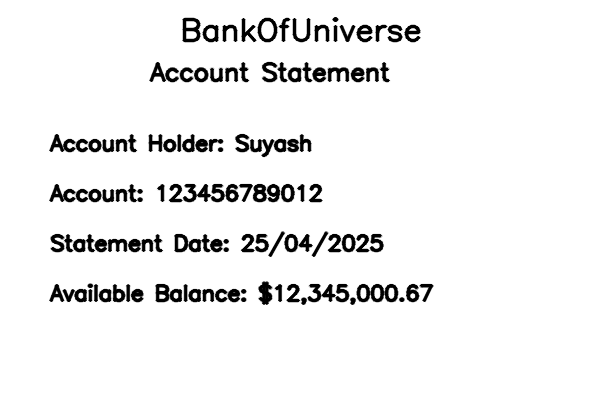

In [44]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Create a blank white image
statement = np.ones((400, 600, 3), dtype=np.uint8) * 255

# Define the bank statement details
bank_name = "BankOfUniverse"
account_holder = "Suyash"
account_number = "123456789012"
statement_date = "25/04/2025"
balance = "$12,345,000.67"

# Set font
font = cv2.FONT_HERSHEY_SIMPLEX

# Write bank statement content
cv2.putText(statement, bank_name, (180, 40), font, 1, (0, 0, 0), 2, cv2.LINE_AA)
cv2.putText(statement, "Account Statement", (150, 80), font, 0.8, (0, 0, 0), 2, cv2.LINE_AA)

cv2.putText(statement, f"Account Holder: {account_holder}", (50, 150), font, 0.7, (0, 0, 0), 2, cv2.LINE_AA)
cv2.putText(statement, f"Account: {account_number}", (50, 200), font, 0.7, (0, 0, 0), 2, cv2.LINE_AA)

cv2.putText(statement, f"Statement Date: {statement_date}", (50, 250), font, 0.7, (0, 0, 0), 2, cv2.LINE_AA)
cv2.putText(statement, f"Available Balance: {balance}", (50, 300), font, 0.7, (0, 0, 0), 2, cv2.LINE_AA)

# Save the bank statement image
cv2.imwrite("sample_bank_statement.png", statement)

# Display the image in Colab
cv2_imshow(statement)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [45]:
processor = DocumentProcessor()
account_info = processor.extract_account_info(image_path="sample_bank_statement.png")
print(account_info)


{'account_number': '123456789012', 'balance': 12345.0, 'date': '2025-04-25', 'confidence': 1.0}
